Perfecto, Genner. Aquí tienes un pipeline completo en Python que parte desde cero con tu archivo original, usando solo las columnas:
- Numéricas: Total, Rating
- Categóricas: Customer type, Gender, Product line, Payment
Incluye:
- 📊 EDA básico
- 🧠 Embedding individual de cada columna categórica
- 📈 Clustering con KMeans
- 🎨 Visualización con PCA y UMAP
- 💻 Todo el código listo para ejecuta


###  1. EDA básico



             Total      Rating
count  1000.000000  1000.00000
mean    322.966749     6.97270
std     245.885335     1.71858
min      10.678500     4.00000
25%     124.422375     5.50000
50%     253.848000     7.00000
75%     471.350250     8.50000
max    1042.650000    10.00000


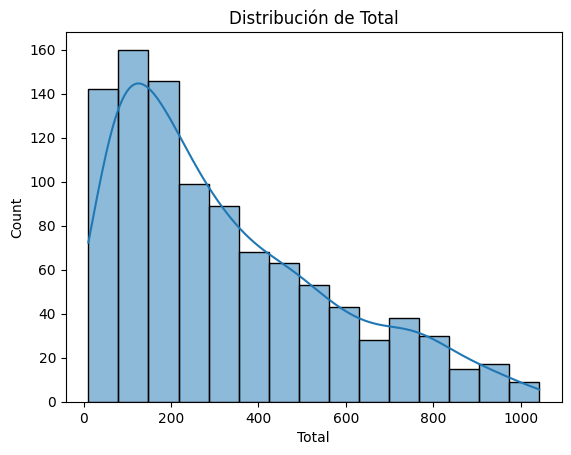

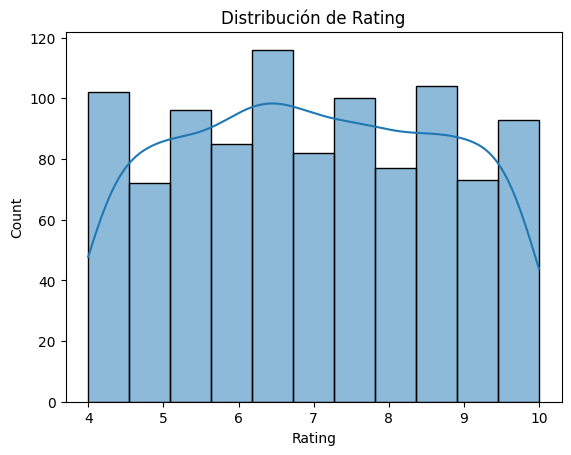


Customer type:
 Customer type
Member    0.501
Normal    0.499
Name: proportion, dtype: float64


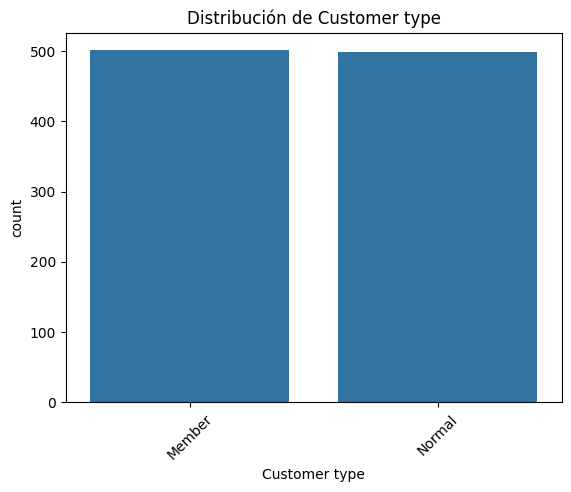


Gender:
 Gender
Female    0.501
Male      0.499
Name: proportion, dtype: float64


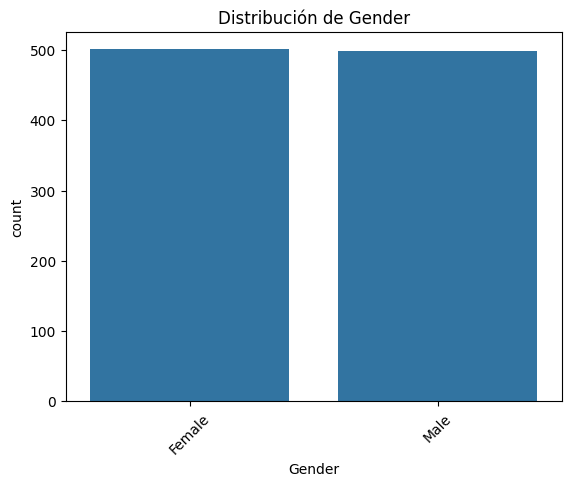


Product line:
 Product line
Fashion accessories       0.178
Food and beverages        0.174
Electronic accessories    0.170
Sports and travel         0.166
Home and lifestyle        0.160
Health and beauty         0.152
Name: proportion, dtype: float64


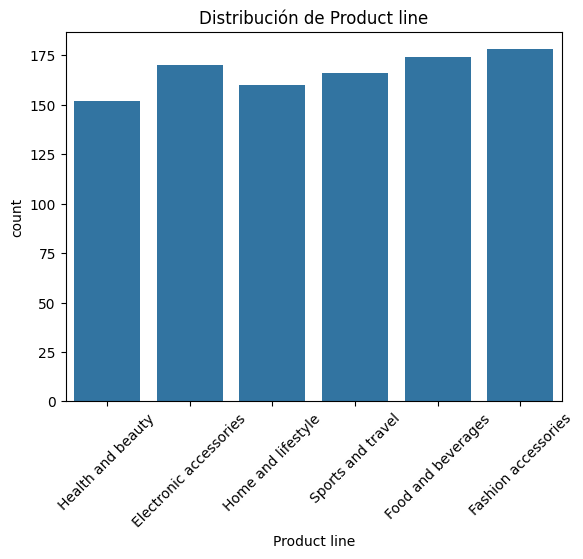


Payment:
 Payment
Ewallet        0.345
Cash           0.344
Credit card    0.311
Name: proportion, dtype: float64


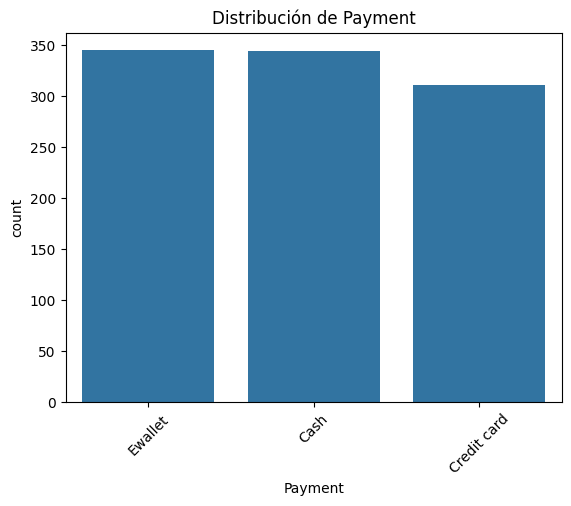

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Cargar datos
df = pd.read_csv("data//clientes.csv")

# Filtrar columnas relevantes
cols = ["Total", "Rating", "Customer type", "Gender", "Product line", "Payment"]
df = df[cols].dropna()

# EDA numéricas
print(df[["Total", "Rating"]].describe())

# Distribuciones
sns.histplot(df["Total"], kde=True)
plt.title("Distribución de Total")
plt.show()

sns.histplot(df["Rating"], kde=True)
plt.title("Distribución de Rating")
plt.show()

# EDA categóricas
for col in ["Customer type", "Gender", "Product line", "Payment"]:
    print(f"\n{col}:\n", df[col].value_counts(normalize=True).round(3))
    sns.countplot(data=df, x=col)
    plt.title(f"Distribución de {col}")
    plt.xticks(rotation=45)
    plt.show()





📊 ANÁLISIS EXPLORATORIO DE DATOS PROFUNDO

🔢 ESTADÍSTICAS DESCRIPTIVAS EXTENDIDAS
----------------------------------------
Estadísticas básicas:
             Total      Rating
count  1000.000000  1000.00000
mean    322.966749     6.97270
std     245.885335     1.71858
min      10.678500     4.00000
25%     124.422375     5.50000
50%     253.848000     7.00000
75%     471.350250     8.50000
max    1042.650000    10.00000

📈 TOTAL:
  • Rango: 10.68 - 1042.65
  • IQR: 346.93
  • Asimetría: 0.891
  • Curtosis: -0.087
  • Coef. Variación: 76.13%

📈 RATING:
  • Rango: 4.00 - 10.00
  • IQR: 3.00
  • Asimetría: 0.009
  • Curtosis: -1.152
  • Coef. Variación: 24.65%

🎯 DETECCIÓN DE OUTLIERS (Método IQR)
----------------------------------------
Total: 9 outliers (0.9%)
Rating: 0 outliers (0.0%)

🔗 MATRIZ DE CORRELACIÓN
----------------------------------------
           Total    Rating
Total   1.000000 -0.036442
Rating -0.036442  1.000000


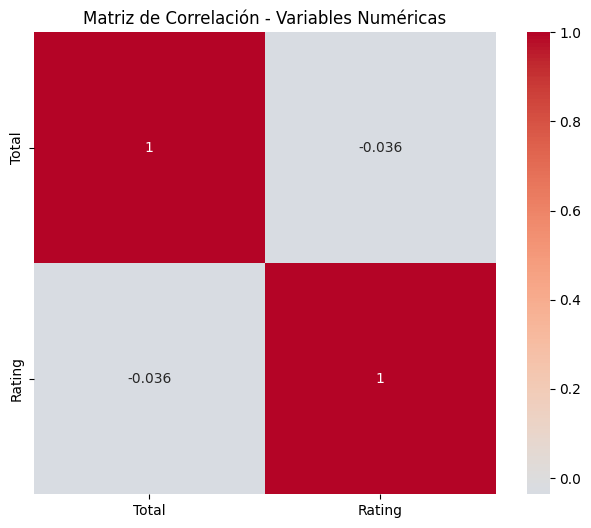


📊 ANÁLISIS DE DISTRIBUCIONES
----------------------------------------


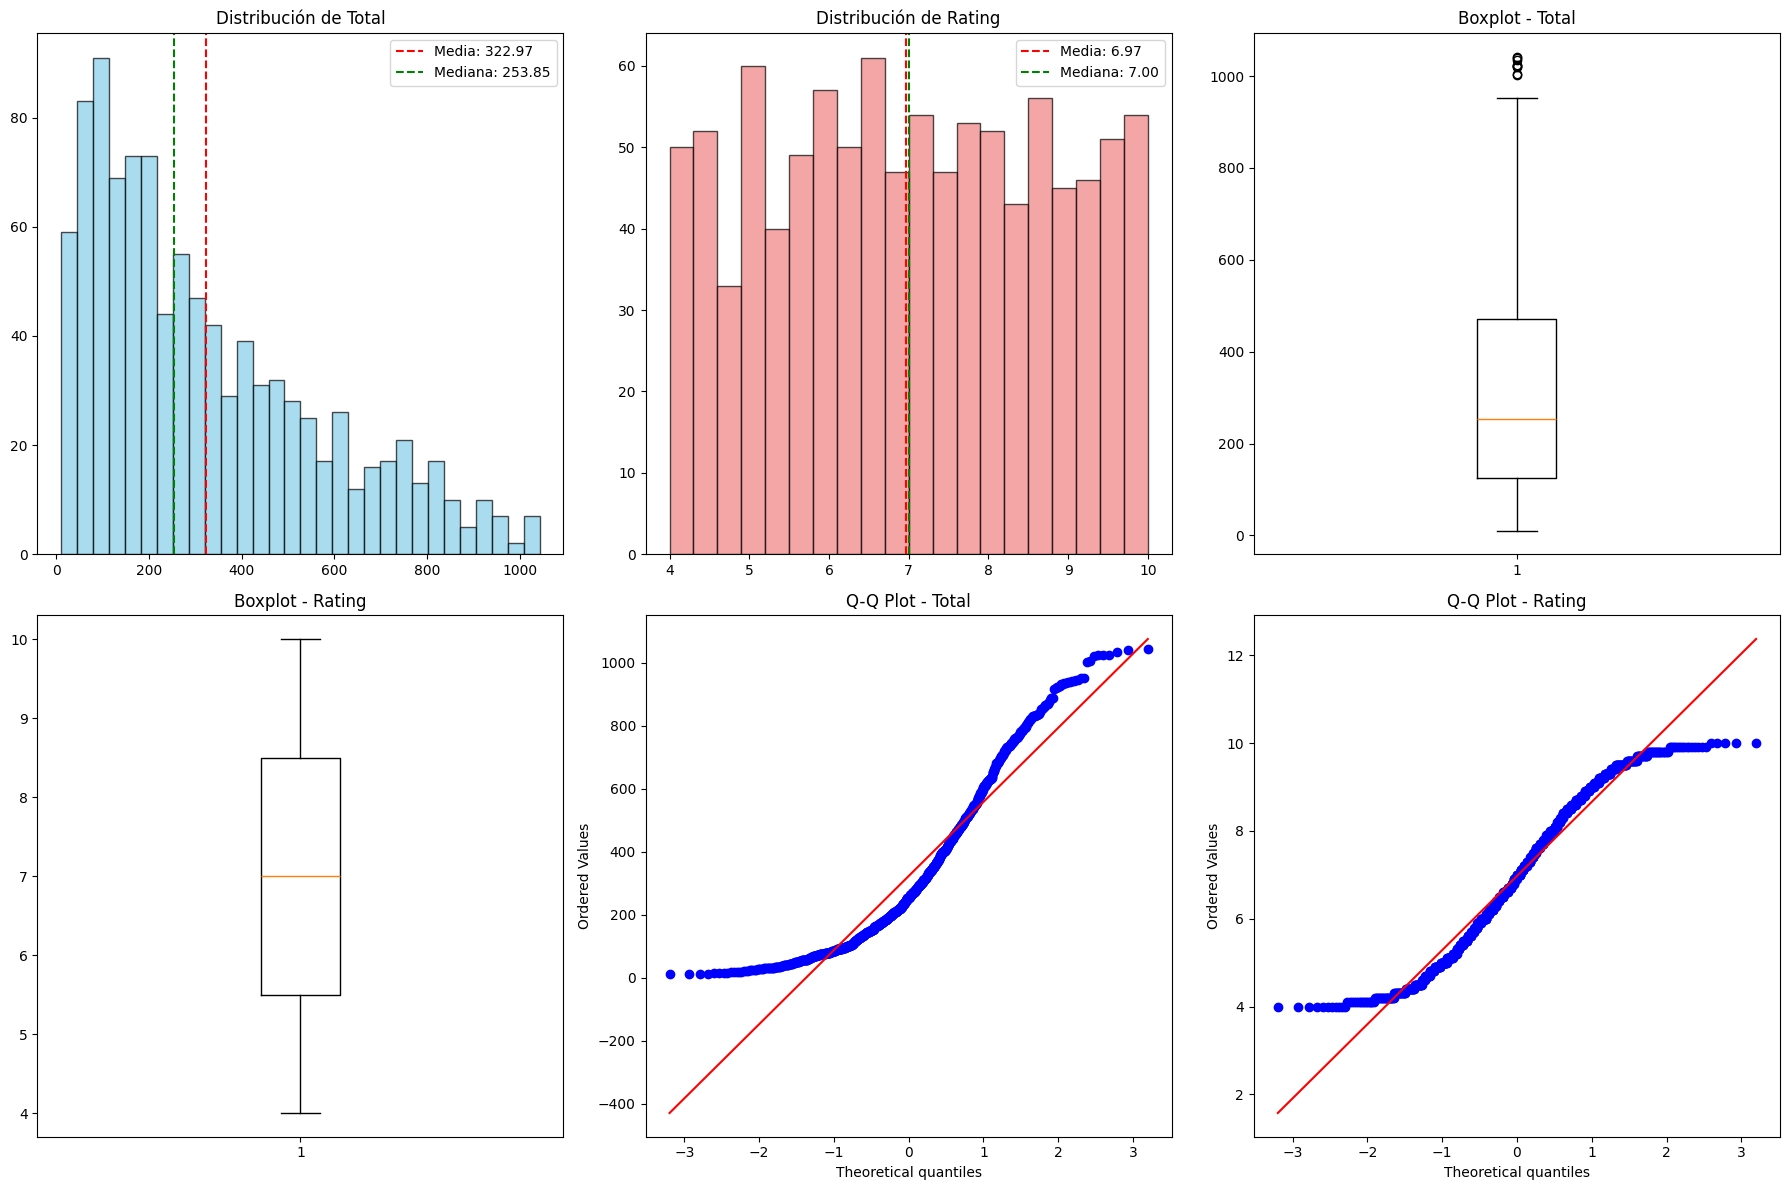


🧪 TESTS DE NORMALIDAD (Shapiro-Wilk)
----------------------------------------
Total: p-value = 0.000000 (No Normal)
Rating: p-value = 0.000000 (No Normal)


In [4]:
import numpy as np
from scipy import stats
import warnings

warnings.filterwarnings('ignore')

print("=" * 50)
print("📊 ANÁLISIS EXPLORATORIO DE DATOS PROFUNDO")
print("=" * 50)

# 1. Estadísticas descriptivas extendidas
print("\n🔢 ESTADÍSTICAS DESCRIPTIVAS EXTENDIDAS")
print("-" * 40)

# Para variables numéricas
numeric_stats = df[["Total", "Rating"]].describe()
print("Estadísticas básicas:")
print(numeric_stats)

# Estadísticas adicionales
for col in ["Total", "Rating"]:
    print(f"\n📈 {col.upper()}:")
    data = df[col]
    print(f"  • Rango: {data.min():.2f} - {data.max():.2f}")
    print(f"  • IQR: {data.quantile(0.75) - data.quantile(0.25):.2f}")
    print(f"  • Asimetría: {stats.skew(data):.3f}")
    print(f"  • Curtosis: {stats.kurtosis(data):.3f}")
    print(f"  • Coef. Variación: {(data.std()/data.mean())*100:.2f}%")

# 2. Análisis de outliers
print("\n🎯 DETECCIÓN DE OUTLIERS (Método IQR)")
print("-" * 40)

for col in ["Total", "Rating"]:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f"{col}: {len(outliers)} outliers ({len(outliers)/len(df)*100:.1f}%)")

# 3. Análisis de correlaciones
print("\n🔗 MATRIZ DE CORRELACIÓN")
print("-" * 40)
correlation = df[["Total", "Rating"]].corr()
print(correlation)

# Visualización de correlación
plt.figure(figsize=(8, 6))
sns.heatmap(correlation, annot=True, cmap='coolwarm', center=0, square=True)
plt.title('Matriz de Correlación - Variables Numéricas')
plt.show()

# 4. Distribuciones con más detalle
print("\n📊 ANÁLISIS DE DISTRIBUCIONES")
print("-" * 40)

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Total
axes[0,0].hist(df['Total'], bins=30, alpha=0.7, color='skyblue', edgecolor='black')
axes[0,0].axvline(df['Total'].mean(), color='red', linestyle='--', label=f'Media: {df["Total"].mean():.2f}')
axes[0,0].axvline(df['Total'].median(), color='green', linestyle='--', label=f'Mediana: {df["Total"].median():.2f}')
axes[0,0].set_title('Distribución de Total')
axes[0,0].legend()

# Rating
axes[0,1].hist(df['Rating'], bins=20, alpha=0.7, color='lightcoral', edgecolor='black')
axes[0,1].axvline(df['Rating'].mean(), color='red', linestyle='--', label=f'Media: {df["Rating"].mean():.2f}')
axes[0,1].axvline(df['Rating'].median(), color='green', linestyle='--', label=f'Mediana: {df["Rating"].median():.2f}')
axes[0,1].set_title('Distribución de Rating')
axes[0,1].legend()

# Boxplots
axes[0,2].boxplot(df['Total'])
axes[0,2].set_title('Boxplot - Total')

axes[1,0].boxplot(df['Rating'])
axes[1,0].set_title('Boxplot - Rating')

# Q-Q plots para normalidad
stats.probplot(df['Total'], dist="norm", plot=axes[1,1])
axes[1,1].set_title('Q-Q Plot - Total')

stats.probplot(df['Rating'], dist="norm", plot=axes[1,2])
axes[1,2].set_title('Q-Q Plot - Rating')

plt.tight_layout()
plt.show()

# 5. Test de normalidad
print("\n🧪 TESTS DE NORMALIDAD (Shapiro-Wilk)")
print("-" * 40)
for col in ["Total", "Rating"]:
    # Para muestras grandes usamos una muestra aleatoria
    sample = df[col].sample(min(5000, len(df))) if len(df) > 5000 else df[col]
    stat, p_value = stats.shapiro(sample)
    print(f"{col}: p-value = {p_value:.6f} {'(Normal)' if p_value > 0.05 else '(No Normal)'}")

In [5]:
# Filtrar registros con Total mayor a 800
high_total_records = df[df['Total'] > 800]

print(f"📊 REGISTROS CON TOTAL > 800")
print(f"Total de registros encontrados: {len(high_total_records)}")
print("=" * 60)

# Mostrar todos los registros
print(high_total_records)

# Estadísticas de estos registros
print(f"\n📈 ESTADÍSTICAS DE REGISTROS CON TOTAL > 800")
print("-" * 40)
print(f"Porcentaje del total: {len(high_total_records)/len(df)*100:.2f}%")
print(f"Total promedio: ${high_total_records['Total'].mean():.2f}")
print(f"Rating promedio: {high_total_records['Rating'].mean():.2f}")

# Análisis por categorías
print(f"\n🏷️ DISTRIBUCIÓN POR CATEGORÍAS")
print("-" * 40)
for col in ["Customer type", "Gender", "Product line", "Payment"]:
    print(f"\n{col}:")
    print(high_total_records[col].value_counts())

📊 REGISTROS CON TOTAL > 800
Total de registros encontrados: 58
         Total  Rating Customer type  Gender            Product line  \
43    829.0800     7.6        Member  Female      Food and beverages   
49    867.6150     7.9        Member  Female     Fashion accessories   
68    827.0850     6.4        Normal    Male       Sports and travel   
70    939.5400     9.6        Normal    Male      Food and beverages   
78    822.2550     6.6        Member  Female      Food and beverages   
96    922.6350     5.1        Normal    Male       Health and beauty   
105   931.0350     7.3        Member    Male  Electronic accessories   
109   860.6850     9.2        Member    Male  Electronic accessories   
120   836.3040     5.2        Normal  Female  Electronic accessories   
122   944.6220     4.2        Member    Male       Sports and travel   
129   853.1460     7.2        Normal  Female       Sports and travel   
140   942.9000     5.4        Member  Female       Sports and travel   
1

Embedding individual de columnas categóricas

In [12]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import TruncatedSVD

# Función para generar embedding por columna
def embed_column(df, col, n_components=2):
    vec = CountVectorizer()
    mat = vec.fit_transform(df[col].astype(str))
    svd = TruncatedSVD(n_components=n_components, random_state=42)
    return svd.fit_transform(mat)

# Embeddings individuales
embed_customer = embed_column(df, "Customer type")
embed_gender = embed_column(df, "Gender")
embed_product = embed_column(df, "Product line")
embed_payment = embed_column(df, "Payment")

# Concatenar embeddings y numéricas
from sklearn.preprocessing import StandardScaler
num_scaled = StandardScaler().fit_transform(df[["Total", "Rating"]])
X = pd.DataFrame(
    np.hstack([num_scaled, embed_customer, embed_gender, embed_product, embed_payment]),
    columns=["Total", "Rating"] + [f"cust_{i}" for i in range(2)] +
            [f"gen_{i}" for i in range(2)] +
            [f"prod_{i}" for i in range(2)] +
            [f"pay_{i}" for i in range(2)]
)

Clustering y visualizacion

In [23]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import umap

# Clustering
k = 4

km = KMeans(n_clusters=k, random_state=42, n_init=10)
labels = km.fit_predict(X)
df["cluster_k4"] = labels

# PCA 2D
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)
df["PC1"] = X_pca[:,0]
df["PC2"] = X_pca[:,1]

# UMAP 2D
reducer = umap.UMAP(n_components=2, random_state=42)
X_umap = reducer.fit_transform(X)
df["UMAP1"] = X_umap[:,0]
df["UMAP2"] = X_umap[:,1]

Gráficos de agrupacione

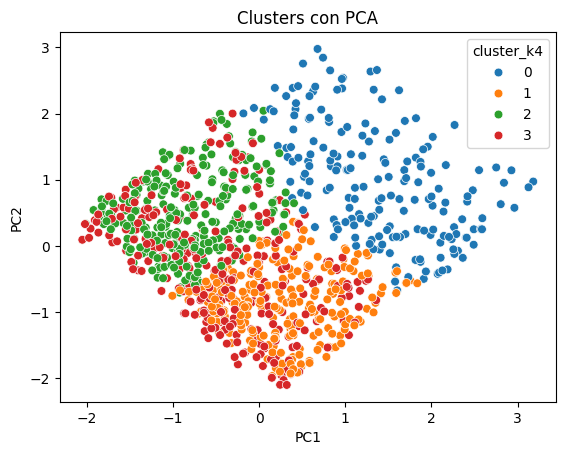

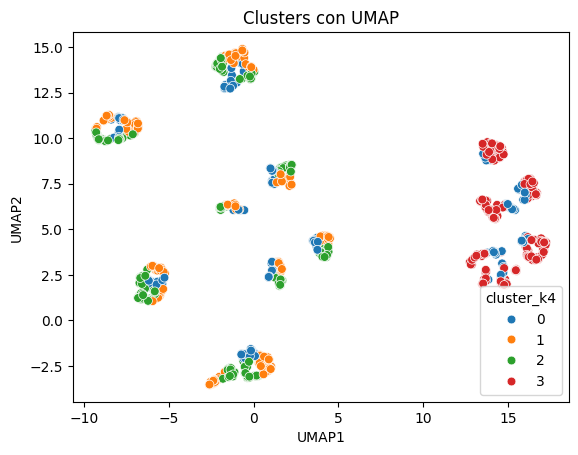

In [24]:
# PCA
sns.scatterplot(data=df, x="PC1", y="PC2", hue="cluster_k4", palette="tab10", s=40)
plt.title("Clusters con PCA")
plt.show()

# UMAP
sns.scatterplot(data=df, x="UMAP1", y="UMAP2", hue="cluster_k4", palette="tab10", s=40)
plt.title("Clusters con UMAP")
plt.show()

In [25]:
# Resumen de variables numéricas por cluster
def cluster_numeric_summary(df, cluster_col, num_cols):
    return df.groupby(cluster_col)[num_cols].agg(["count", "mean", "std"]).round(2)

# Columnas numéricas
num_cols = ["Total", "Rating"]

# Ejecutar resumen
numeric_summary = cluster_numeric_summary(df, "cluster_k4", num_cols)
print("Resumen numérico por cluster:")
print(numeric_summary)

Resumen numérico por cluster:
           Total                 Rating            
           count    mean     std  count  mean   std
cluster_k4                                         
0            188  734.96  135.01    188  6.55  1.66
1            259  217.60  137.19    259  5.55  0.90
2            266  243.75  154.36    266  8.52  0.84
3            287  221.59  149.77    287  7.09  1.71


In [26]:
# Proporciones de categorías por cluster
def cluster_category_summary(df, cluster_col, cat_cols, top_n=3):
    result = {}
    for cluster in sorted(df[cluster_col].unique()):
        sub = df[df[cluster_col] == cluster]
        summary = {}
        for col in cat_cols:
            vc = sub[col].value_counts(normalize=True).head(top_n)
            summary[col] = "; ".join([f"{idx} ({round(val*100,1)}%)" for idx, val in vc.items()])
        result[cluster] = summary
    return pd.DataFrame(result).T

# Columnas categóricas
cat_cols = ["Customer type", "Gender", "Product line", "Payment"]

# Ejecutar resumen
category_summary = cluster_category_summary(df, "cluster_k4", cat_cols)
print("\nProporciones de categorías por cluster:")
print(category_summary)


Proporciones de categorías por cluster:
                    Customer type                        Gender  \
0  Member (53.2%); Normal (46.8%)  Female (55.3%); Male (44.7%)   
1  Normal (51.4%); Member (48.6%)  Male (56.4%); Female (43.6%)   
2  Member (52.3%); Normal (47.7%)  Female (50.0%); Male (50.0%)   
3  Normal (52.6%); Member (47.4%)  Female (52.6%); Male (47.4%)   

                                        Product line  \
0  Home and lifestyle (19.1%); Sports and travel ...   
1  Sports and travel (28.6%); Food and beverages ...   
2  Food and beverages (30.1%); Health and beauty ...   
3  Fashion accessories (52.3%); Electronic access...   

                                             Payment  
0  Cash (34.6%); Credit card (34.0%); Ewallet (31...  
1  Ewallet (39.0%); Cash (31.3%); Credit card (29...  
2  Ewallet (33.5%); Cash (33.5%); Credit card (33...  
3  Cash (38.0%); Ewallet (33.4%); Credit card (28...  


In [21]:
# Buyer personas y campañas sugeridas por cluster
buyer_personas = {
    0: {
        "nombre": "Premium Explorer",
        "perfil": "Alto ticket, productos premium, predominio de miembros y pagos digitales.",
        "campaña": "Acceso VIP a lanzamientos exclusivos. Canal: email personalizado + app."
    },
    1: {
        "nombre": "Frequent High-Value",
        "perfil": "Compras frecuentes de alto valor, mezcla de productos caros.",
        "campaña": "Bundles y recompensas por volumen. Canal: email + remarketing."
    },
    2: {
        "nombre": "Everyday Shopper",
        "perfil": "Gasto medio, productos de hogar y alimentos, compras regulares.",
        "campaña": "Ofertas semanales y cupones por volumen. Canal: push + cupones."
    },
    3: {
        "nombre": "Style Seeker",
        "perfil": "Moda y accesorios, gasto medio-bajo, alto rating.",
        "campaña": "Lanzamientos y recomendaciones personalizadas. Canal: redes + email."
    },
    4: {
        "nombre": "Low-Ticket Loyal",
        "perfil": "Compras pequeñas frecuentes, alto rating, preferencia por efectivo.",
        "campaña": "Cupones inmediatos y fidelidad por visitas. Canal: SMS + punto de venta."
    }
}

# Mostrar resumen
print("\nBuyer personas y campañas sugeridas:")
for cluster, info in buyer_personas.items():
    print(f"\nCluster {cluster} → {info['nombre']}")
    print(f"Perfil: {info['perfil']}")
    print(f"Campaña sugerida: {info['campaña']}")


Buyer personas y campañas sugeridas:

Cluster 0 → Premium Explorer
Perfil: Alto ticket, productos premium, predominio de miembros y pagos digitales.
Campaña sugerida: Acceso VIP a lanzamientos exclusivos. Canal: email personalizado + app.

Cluster 1 → Frequent High-Value
Perfil: Compras frecuentes de alto valor, mezcla de productos caros.
Campaña sugerida: Bundles y recompensas por volumen. Canal: email + remarketing.

Cluster 2 → Everyday Shopper
Perfil: Gasto medio, productos de hogar y alimentos, compras regulares.
Campaña sugerida: Ofertas semanales y cupones por volumen. Canal: push + cupones.

Cluster 3 → Style Seeker
Perfil: Moda y accesorios, gasto medio-bajo, alto rating.
Campaña sugerida: Lanzamientos y recomendaciones personalizadas. Canal: redes + email.

Cluster 4 → Low-Ticket Loyal
Perfil: Compras pequeñas frecuentes, alto rating, preferencia por efectivo.
Campaña sugerida: Cupones inmediatos y fidelidad por visitas. Canal: SMS + punto de venta.
